In [2]:
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
import joblib

In [5]:
questions = pd.read_csv("data/processed/question_info.csv")

company_question = pd.read_csv("data/processed/company_question.csv")

company_tags = pd.read_csv("data/processed/all_company_tags.csv")

company_features = pd.read_csv("data/processed/all_company_feature_final.csv")

metadata = pd.read_csv("question_embedding_metadata.csv")

question_embeddings = np.load("question_embeddings.npy")

company_embeddings = pd.read_csv("company_embedding_mean.csv")

In [20]:
metadata['Title'].duplicated().sum()

np.int64(6)

In [21]:
question_embedding = dict(
    zip(
        metadata.ID,
        question_embeddings
    )
)

In [22]:
company_embedding = {}

for _, row in company_embeddings.iterrows():

    company_embedding[row.company] = row.iloc[1:].values

In [23]:
question_lookup = questions.set_index("ID")

In [24]:
target_company = "google"

solved_questions = [
    1,
    12,
    38,
    62,
    119
]

In [25]:
user_vector = np.mean(
    [question_embedding[q] for q in solved_questions],
    axis=0
)

In [26]:
#normalize
user_vector = user_vector / np.linalg.norm(user_vector)

In [27]:
#Only consider questions asked by the company
candidate_ids = company_question.loc[
    company_question.company == target_company,
    "ID"
].unique()

In [28]:
#Remove solved
candidate_ids = [
    q
    for q in candidate_ids
    if q not in solved_questions
]

In [30]:
company_question

,company,company_tier,ID
0,1kosmos,Tier_C,2938
1,6sense,Tier_C,2571
2,6sense,Tier_C,1105
3,6sense,Tier_C,1894
4,6sense,Tier_C,1497
...,...,...,...
17636,zscaler,Tier_C,273
17637,zulily,Tier_C,20
17638,zulily,Tier_C,45
17639,zynga,Tier_C,206


In [31]:
# freq_lookup = {}

# temp = company_question[
#     company_question.company == target_company
# ]

# max_freq = temp.frequency.max()

# for _, row in temp.iterrows():

#     freq_lookup[row.ID] = (
#         row.frequency / max_freq
#     )

In [34]:
import re
def clean_tag(tag):

    if tag is None:
        return None

    tag = str(tag).strip()

    # remove common garbage
    tag = tag.strip("()[]{}")
    tag = tag.strip("'\"")
    tag = tag.strip(",")

    # normalize whitespace
    tag = re.sub(r"\s+", " ", tag)

    # canonical casing
    tag = tag.title()

    if not tag:
        return None

    return tag
            

In [35]:
def parse_topics(topic):

    if topic is None:
        return []

    if isinstance(topic, float) and pd.isna(topic):
        return []

    if isinstance(topic, (list, tuple, set)):
        return [
            clean_tag(t)
            for t in topic
            if clean_tag(t)
        ]

    if isinstance(topic, str):

        try:
            parsed = ast.literal_eval(topic)

            if isinstance(parsed, (list, tuple)):
                return [
                    clean_tag(t)
                    for t in parsed
                    if clean_tag(t)
                ]

            return [clean_tag(parsed)]

        except:
            pass

        # fallback for malformed strings
        topic = re.sub(r"[\(\)\[\]]", "", topic)

        return [
            clean_tag(t)
            for t in topic.split(",")
            if clean_tag(t)
        ]

    return []

In [45]:
from collections import Counter

counter = Counter()

for q in solved_questions:

    cleaned_tags = parse_topics(question_lookup.loc[q, "topics"])
    tags = ['Heap (Priority Queue)' if item == 'Heap (Priority Queue' else item for item in cleaned_tags]

    counter.update(tags)

In [47]:
#normalize
total = sum(counter.values())

user_topic = {}

for k,v in counter.items():

    user_topic[k] = v / total

{'Array': 0.18181818181818182,
 'Hash Table': 0.18181818181818182,
 'Math': 0.18181818181818182,
 'String': 0.18181818181818182,
 'Dynamic Programming': 0.18181818181818182,
 'Combinatorics': 0.09090909090909091}

In [49]:
#company profile
company_profile = company_tags[
    company_tags.company == target_company
]

In [50]:
#to dict
company_profile = (
    company_profile
    .drop(columns="company")
    .iloc[0]
    .to_dict()
)

In [53]:
s = sum(company_profile.values())

company_profile = {
    k:v/s
    for k,v in company_profile.items()
}

In [ ]:
company_profile

167

In [77]:
gap = np.mean([
        topic_gap.get(tag,0)
        for tag in tags
    ])
gap

np.float64(-0.06960092596012954)

In [54]:
#gap
topic_gap = {}

for tag in company_profile:

    topic_gap[tag] = (

        company_profile[tag]

        -

        user_topic.get(tag,0)

    )

In [55]:
#avg difficulty solved
avg_user_difficulty = (

question_lookup

.loc[solved_questions]

.difficulty_score

.mean()

)

In [59]:
def compute_score(question_id):

    embedding = question_embedding[question_id]

    semantic = cosine_similarity(
        user_vector.reshape(1,-1),
        embedding.reshape(1,-1)
    )[0,0]

    cleaned_tags = parse_topics(question_lookup.loc[question_id, "topics"])
    tags = ['Heap (Priority Queue)' if item == 'Heap (Priority Queue' else item for item in cleaned_tags]
    

    gap = np.mean([
        topic_gap.get(tag,0)
        for tag in tags
    ])

    difficulty = question_lookup.loc[
        question_id,
        "difficulty_score"
    ]

    difficulty_score = 1 - (
        abs(
            difficulty
            -
            avg_user_difficulty
        ) / 3
    )

    score = (

        0.55*semantic

        +

        0.30*gap

        +

        0.15*difficulty_score

    )

    return score

In [65]:
results = []

for q in candidate_ids:

    score = compute_score(q)

    results.append({

        "ID":q,

        "score":score

    })

e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encount

In [66]:
recommendation = (

pd.DataFrame(results)

.sort_values(

"score",

ascending=False

)

)

In [67]:
recommendation = recommendation.merge(

questions[

[

"ID",

"Title",

"Difficulty",

"topics",

"acceptance_pct"

]

],

on="ID"

)

In [91]:
recommendation.head(20)

,ID,score,Title,Difficulty,topics,acceptance_pct
0,945,0.566974,Minimum Increment to Make Array Unique,Medium,"['Array', 'Greedy', 'Sorting', 'Counting']",60.7
1,1498,0.563489,Number of Subsequences That Satisfy the Given ...,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",49.2
2,18,0.562651,4Sum,Medium,"['Array', 'Two Pointers', 'Sorting']",40.6
3,2996,0.561211,Smallest Missing Integer Greater Than Sequenti...,Easy,"['Array', 'Hash Table', 'Sorting']",35.5
4,1004,0.559797,Max Consecutive Ones III,Medium,"['Array', 'Binary Search', 'Sliding Window', '...",67.7
5,2563,0.559619,Count the Number of Fair Pairs,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",52.7
6,167,0.554619,Two Sum II - Input Array Is Sorted,Medium,"['Array', 'Two Pointers', 'Binary Search']",65.1
7,2048,0.552723,Next Greater Numerically Balanced Number,Medium,"['Hash Table', 'Math', 'Backtracking', 'Counti...",63.1
8,633,0.551558,Sum of Square Numbers,Medium,"['Math', 'Two Pointers', 'Binary Search']",36.9
9,1995,0.550929,Count Special Quadruplets,Easy,"['Array', 'Hash Table', 'Enumeration']",64.7


In [115]:
def explain(question_id):

    cleaned_tags = parse_topics(question_lookup.loc[
        question_id,
        "topics"
    ])
    tags = ['Heap (Priority Queue)' if item == 'Heap (Priority Queue' else item for item in cleaned_tags]

    return {

        "Topic Gap":
           np.mean([
            topic_gap.get(t,0)
            for t in tags
        ]),

        "Difficulty":
        question_lookup.loc[
            question_id,
            "Difficulty"
        ]
    }

In [116]:
a = recommendation.copy()

In [117]:
a['explanation'] = a['ID'].apply(explain)

e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
e:\interview preparation guide\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,ID,score,Title,Difficulty,topics,acceptance_pct,explanation
0,945,0.566974,Minimum Increment to Make Array Unique,Medium,"['Array', 'Greedy', 'Sorting', 'Counting']",60.7,"{'Topic Gap': 0.019661261128144508, 'Difficult..."
1,1498,0.563489,Number of Subsequences That Satisfy the Given ...,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",49.2,"{'Topic Gap': 0.02064324677083718, 'Difficulty..."
2,18,0.562651,4Sum,Medium,"['Array', 'Two Pointers', 'Sorting']",40.6,"{'Topic Gap': 0.017636749453084275, 'Difficult..."
3,2996,0.561211,Smallest Missing Integer Greater Than Sequenti...,Easy,"['Array', 'Hash Table', 'Sorting']",35.5,"{'Topic Gap': -0.028612003825331748, 'Difficul..."
4,1004,0.559797,Max Consecutive Ones III,Medium,"['Array', 'Binary Search', 'Sliding Window', '...",67.7,"{'Topic Gap': 0.013464593107014883, 'Difficult..."
...,...,...,...,...,...,...,...
2264,2625,NaN,Flatten Deeply Nested Array,Medium,[],65.9,"{'Topic Gap': nan, 'Difficulty': 'Medium'}"
2265,2630,NaN,Memoize II,Hard,[],38.9,"{'Topic Gap': nan, 'Difficulty': 'Hard'}"
2266,2622,NaN,Cache With Time Limit,Medium,[],76.1,"{'Topic Gap': nan, 'Difficulty': 'Medium'}"
2267,2715,NaN,Timeout Cancellation,Easy,[],89.6,"{'Topic Gap': nan, 'Difficulty': 'Easy'}"


In [119]:
recommendation

,ID,score,Title,Difficulty,topics,acceptance_pct
0,945,0.566974,Minimum Increment to Make Array Unique,Medium,"['Array', 'Greedy', 'Sorting', 'Counting']",60.7
1,1498,0.563489,Number of Subsequences That Satisfy the Given ...,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",49.2
2,18,0.562651,4Sum,Medium,"['Array', 'Two Pointers', 'Sorting']",40.6
3,2996,0.561211,Smallest Missing Integer Greater Than Sequenti...,Easy,"['Array', 'Hash Table', 'Sorting']",35.5
4,1004,0.559797,Max Consecutive Ones III,Medium,"['Array', 'Binary Search', 'Sliding Window', '...",67.7
...,...,...,...,...,...,...
2264,2625,NaN,Flatten Deeply Nested Array,Medium,[],65.9
2265,2630,NaN,Memoize II,Hard,[],38.9
2266,2622,NaN,Cache With Time Limit,Medium,[],76.1
2267,2715,NaN,Timeout Cancellation,Easy,[],89.6


In [120]:
NUM_WEEKS = 8

QUESTIONS_PER_WEEK = 5

In [121]:
roadmap_questions = recommendation.head(

NUM_WEEKS * QUESTIONS_PER_WEEK

).copy()

In [122]:
difficulty_map = {

"Easy":1,

"Medium":2,

"Hard":3

}

In [123]:
roadmap_questions["difficulty_score"] = (

roadmap_questions["Difficulty"]

.map(difficulty_map)

)

In [125]:
roadmap_questions

,ID,score,Title,Difficulty,topics,acceptance_pct,difficulty_score
0,945,0.566974,Minimum Increment to Make Array Unique,Medium,"['Array', 'Greedy', 'Sorting', 'Counting']",60.7,2
1,1498,0.563489,Number of Subsequences That Satisfy the Given ...,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",49.2,2
2,18,0.562651,4Sum,Medium,"['Array', 'Two Pointers', 'Sorting']",40.6,2
3,2996,0.561211,Smallest Missing Integer Greater Than Sequenti...,Easy,"['Array', 'Hash Table', 'Sorting']",35.5,1
4,1004,0.559797,Max Consecutive Ones III,Medium,"['Array', 'Binary Search', 'Sliding Window', '...",67.7,2
5,2563,0.559619,Count the Number of Fair Pairs,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",52.7,2
6,167,0.554619,Two Sum II - Input Array Is Sorted,Medium,"['Array', 'Two Pointers', 'Binary Search']",65.1,2
7,2048,0.552723,Next Greater Numerically Balanced Number,Medium,"['Hash Table', 'Math', 'Backtracking', 'Counti...",63.1,2
8,633,0.551558,Sum of Square Numbers,Medium,"['Math', 'Two Pointers', 'Binary Search']",36.9,2
9,1995,0.550929,Count Special Quadruplets,Easy,"['Array', 'Hash Table', 'Enumeration']",64.7,1


In [136]:
roadmap_questions["primary_topic"] = (
    roadmap_questions["topics"]
    .apply(parse_topics)
    .str[0]
    .replace({"Heap (Priority Queue": "Heap (Priority Queue)"})
)

In [138]:
roadmap_questions = roadmap_questions.sort_values(

["difficulty_score","score"],

ascending=[True,False]

)

In [139]:
topic_groups = {}

for topic,group in roadmap_questions.groupby(

"primary_topic"

):

    topic_groups[topic] = group.copy()

Now every topic has its own mini dataframe.

Example

Graph

↓

10 questions

DP

↓

8 questions

Tree

↓

5 questions

In [141]:
weeks = {}

for week in range(

1,

NUM_WEEKS+1

):

    weeks[week] = []

In [142]:
#Instead of putting all Graph questions in Week 1, distribute topics.
week = 1

for topic in topic_groups:

    for _,row in topic_groups[topic].iterrows():

        weeks[week].append(row)

        week += 1

        if week > NUM_WEEKS:

            week = 1

In [143]:
for week in weeks:

    weeks[week] = weeks[week][:QUESTIONS_PER_WEEK]

In [145]:
roadmap = []

for week in weeks:

    for row in weeks[week]:

        roadmap.append({

            "Week":week,

            "Question ID":row.ID,

            "Title":row.Title,

            "Difficulty":row.Difficulty,

            "Topic":row.primary_topic,

            "Recommendation Score":row.score

        })

In [146]:
roadmap = pd.DataFrame(roadmap)

In [147]:
roadmap = roadmap.sort_values(

["Week","Recommendation Score"],

ascending=[True,False]

)

In [148]:
roadmap

,Week,Question ID,Title,Difficulty,Topic,Recommendation Score
0,1,2996,Smallest Missing Integer Greater Than Sequenti...,Easy,Array,0.561211
2,1,2150,Find All Lonely Numbers in the Array,Medium,Array,0.549718
4,1,3133,Minimum Array End,Medium,Bit Manipulation,0.544591
3,1,287,Find the Duplicate Number,Medium,Array,0.542137
1,1,2206,Divide Array Into Equal Pairs,Easy,Array,0.539455
5,2,1995,Count Special Quadruplets,Easy,Array,0.550929
9,2,386,Lexicographical Numbers,Medium,Depth-First Search,0.550204
7,2,2155,All Divisions With the Highest Score of a Bina...,Medium,Array,0.548710
8,2,2275,Largest Combination With Bitwise AND Greater T...,Medium,Array,0.541580
6,2,2057,Smallest Index With Equal Value,Easy,Array,0.539451


<Axes: xlabel='Week'>

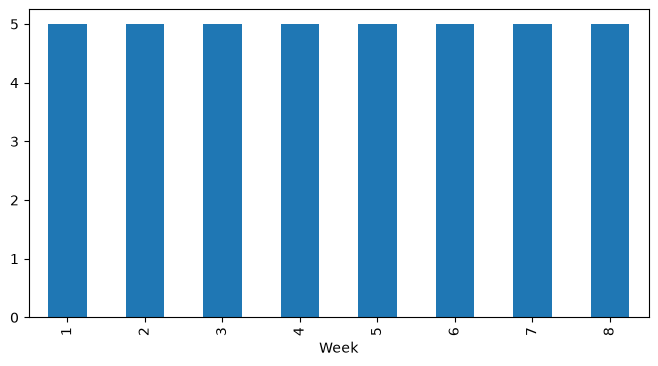

In [149]:
roadmap.groupby("Week").size().plot.bar(

figsize=(8,4)

)

In [150]:
roadmap.groupby(

"Week"

)["Difficulty"].value_counts()

Week  Difficulty
1     Medium        3
      Easy          2
2     Medium        3
      Easy          2
3     Medium        3
      Easy          2
4     Medium        4
      Easy          1
5     Medium        3
      Easy          2
6     Medium        4
      Easy          1
7     Medium        4
      Easy          1
8     Medium        4
      Easy          1
Name: count, dtype: int64

In [151]:
embedding_lookup = dict(

zip(

metadata.ID,

question_embeddings

)

)

In [152]:
company = "google"

profile = company_tags[
    company_tags.company==company
]

profile = profile.drop(
    columns="company"
).iloc[0]

In [153]:
profile = profile / profile.sum()

In [155]:
topic_priority = profile.sort_values(
    ascending=False
)

In [192]:
recommendation.drop(columns = ['difficulty_score','primary_topic','topic_priority','embedding','priority'],inplace = True)

In [197]:
recommendation["difficulty_score"] = (

recommendation.Difficulty

.map(difficulty_map)

)

In [199]:
recommendation["primary_topic"] = (
    recommendation["topics"]
    .apply(parse_topics)
    .str[0]
    .replace({"Heap (Priority Queue": "Heap (Priority Queue)"})
)

In [209]:
recommendation["topic_priority"] = (

recommendation.primary_topic

.map(topic_priority)

.fillna(0)

)

In [207]:
recommendation["embedding"] = (

recommendation.ID

.map(embedding_lookup)

)

In [212]:
recommendation

,ID,score,Title,Difficulty,topics,acceptance_pct,difficulty_score,primary_topic,embedding,topic_priority,priority
0,945,0.566974,Minimum Increment to Make Array Unique,Medium,"['Array', 'Greedy', 'Sorting', 'Counting']",60.7,2,Array,"[0.04204395, 0.037426237, -0.07809477, -0.1036...",0.172017,0.448487
1,1498,0.563489,Number of Subsequences That Satisfy the Given ...,Medium,"['Array', 'Two Pointers', 'Binary Search', 'So...",49.2,2,Array,"[-0.032277144, 0.014312433, -0.040723305, -0.0...",0.172017,0.446048
2,18,0.562651,4Sum,Medium,"['Array', 'Two Pointers', 'Sorting']",40.6,2,Array,"[0.040802088, 0.031713877, -0.08269722, -0.126...",0.172017,0.445461
3,2996,0.561211,Smallest Missing Integer Greater Than Sequenti...,Easy,"['Array', 'Hash Table', 'Sorting']",35.5,1,Array,"[0.0044959798, 0.02767143, -0.033785746, -0.08...",0.172017,0.444453
4,1004,0.559797,Max Consecutive Ones III,Medium,"['Array', 'Binary Search', 'Sliding Window', '...",67.7,2,Array,"[-0.0046611386, 0.007953586, -0.06289153, -0.1...",0.172017,0.443463
...,...,...,...,...,...,...,...,...,...,...,...
2264,2625,NaN,Flatten Deeply Nested Array,Medium,[],65.9,2,NaN,"[-0.072799675, 0.010986516, -0.0058007617, -0....",0.000000,NaN
2265,2630,NaN,Memoize II,Hard,[],38.9,3,NaN,"[-0.069953494, 0.013918017, -0.052015778, 0.01...",0.000000,NaN
2266,2622,NaN,Cache With Time Limit,Medium,[],76.1,2,NaN,"[-0.069662906, 0.053233985, -0.031828158, 0.00...",0.000000,NaN
2267,2715,NaN,Timeout Cancellation,Easy,[],89.6,1,NaN,"[-0.04043526, 0.06428139, -0.001954888, 0.0205...",0.000000,NaN


In [211]:
recommendation["priority"] = (

0.7*recommendation.score

+

0.3*recommendation.topic_priority

)

In [213]:
recommendation = recommendation.sort_values(

"priority",

ascending=False

)

In [168]:
NUM_WEEKS = 8

QUESTIONS_PER_WEEK = 5

MAX_TOPIC_PER_WEEK = 2

SIM_THRESHOLD = 0.80

In [214]:
roadmap = {

week:[]

for week in range(

1,

NUM_WEEKS+1

)

}

In [215]:
#Semantic diversity
def is_diverse(

candidate,

week_questions,

threshold=0.80

):

    if len(week_questions)==0:

        return True

    cand = embedding_lookup[candidate]

    for q in week_questions:

        sim = cosine_similarity(

cand.reshape(1,-1),

embedding_lookup[q].reshape(1,-1)

)[0,0]

        if sim > threshold:

            return False

    return True

In [216]:
scheduled = set()

In [228]:
for week in range(1,NUM_WEEKS+1):

    topic_counter = {}

    target_difficulty = min(3,1 + (week-1)*0.3)

    week_questions = []
    for _,row in recommendation.iterrows():

        qid = row.ID

        if qid in scheduled:
            continue
        if abs(row.difficulty_score - target_difficulty)>1:
            continue
        topic = row.primary_topic
        if topic_counter.get(topic,0)>=MAX_TOPIC_PER_WEEK:
            continue
        if not is_diverse(qid,week_questions,SIM_THRESHOLD):
           continue
        
        week_questions.append(qid)
        scheduled.add(qid)
        topic_counter[topic] = (topic_counter.get(topic,0)+1)

        if len(week_questions)==QUESTIONS_PER_WEEK:
          break
    roadmap[week]=week_questions

In [229]:
roadmap

{1: [1346, 942, 476, 1915, 653],
 2: [2006, 1920, 1291, 1888, 1850],
 3: [496, 1827, 2769, 3304, 1545],
 4: [2542, 40, 2169, 504, 1387],
 5: [2780, 3404, 1492, 1079, 2982],
 6: [2221, 229, 96, 1737, 129],
 7: [1855, 1814, 1405, 1061, 738],
 8: [1838, 3362, 2429, 3129, 3085]}

In [230]:
rows=[]
for week,questions_ in roadmap.items():

    for q in questions_:

        info = recommendation[
            recommendation.ID==q
        ].iloc[0]

        rows.append({

            "Week":week,

            "Question ID":q,

            "Title":info.Title,

            "Difficulty":info.Difficulty,

            "Topic":info.primary_topic,

            "Score":info.score

        })

In [231]:
roadmap_df = pd.DataFrame(rows)

In [232]:
roadmap_df

,Week,Question ID,Title,Difficulty,Topic,Score
0,1,1346,Check If N and Its Double Exist,Easy,Array,0.534084
1,1,942,DI String Match,Easy,Array,0.532593
2,1,476,Number Complement,Easy,Bit Manipulation,0.513582
3,1,1915,Number of Wonderful Substrings,Medium,Hash Table,0.490596
4,1,653,Two Sum IV - Input is a BST,Easy,Hash Table,0.490509
5,2,2006,Count Number of Pairs With Absolute Difference K,Easy,Array,0.532482
6,2,1920,Build Array from Permutation,Easy,Array,0.531727
7,2,1291,Sequential Digits,Medium,Enumeration,0.514299
8,2,1888,Minimum Number of Flips to Make the Binary Str...,Medium,String,0.487377
9,2,1850,Minimum Adjacent Swaps to Reach the Kth Smalle...,Medium,Two Pointers,0.508215


In [233]:
roadmap_df.groupby(

"Week"

)["Difficulty"].value_counts()

Week  Difficulty
1     Easy          4
      Medium        1
2     Medium        3
      Easy          2
3     Easy          4
      Medium        1
4     Medium        3
      Easy          2
5     Medium        5
6     Medium        5
7     Medium        5
8     Medium        5
Name: count, dtype: int64

In [234]:
roadmap_df.groupby(

"Week"

)["Topic"].value_counts()

Week  Topic              
1     Array                  2
      Hash Table             2
      Bit Manipulation       1
2     Array                  2
      Enumeration            1
      String                 1
      Two Pointers           1
3     Array                  2
      Math                   2
      String                 1
4     Array                  2
      Math                   2
      Dynamic Programming    1
5     Array                  2
      Hash Table             2
      Math                   1
6     Array                  2
      Math                   1
      Hash Table             1
      Tree                   1
7     Array                  2
      String                 2
      Math                   1
8     Array                  2
      Greedy                 1
      Dynamic Programming    1
      Hash Table             1
Name: count, dtype: int64

In [235]:
roadmap_df.groupby(

"Week"

)["Score"].mean()

Week
1    0.512273
2    0.514820
3    0.507470
4    0.508154
5    0.504917
6    0.506703
7    0.500960
8    0.503739
Name: Score, dtype: float64

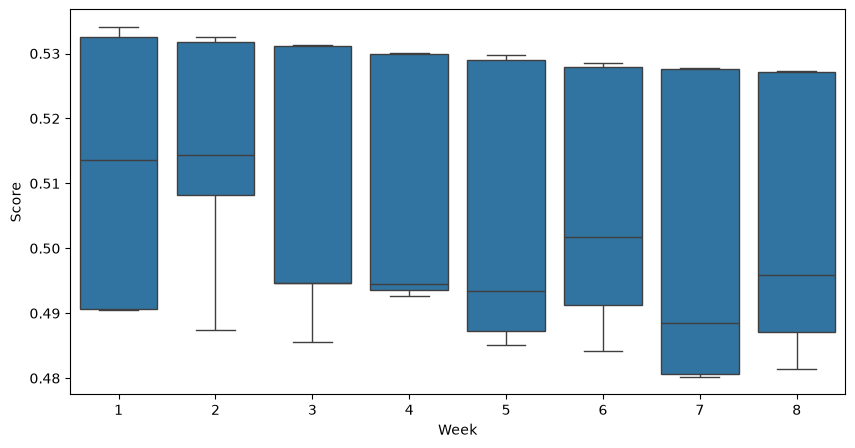

In [236]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(

data=roadmap_df,

x="Week",

y="Score"

)

plt.show()

<Axes: xlabel='Topic', ylabel='Week'>

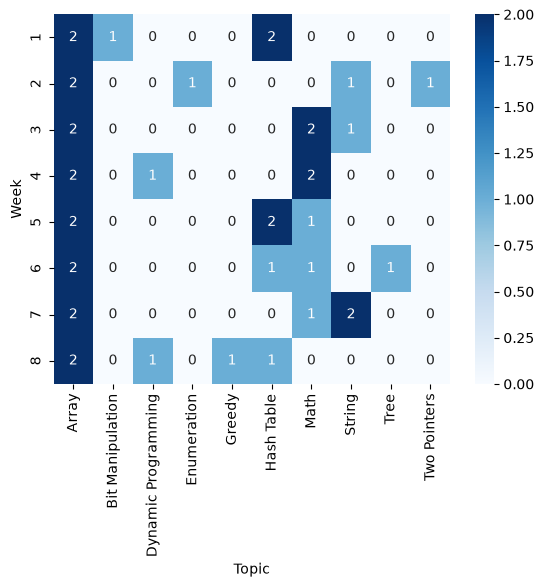

In [237]:
pivot = pd.crosstab(

roadmap_df.Week,

roadmap_df.Topic

)

sns.heatmap(

pivot,

annot=True,

cmap="Blues"

)

his is good, but here's how I'd make it interview-level

Right now, the scheduler loops over all recommendations every week. That's acceptable for 3,300 questions, but the algorithm still relies on a fixed weighted priority (0.7 * score + 0.3 * topic_priority).

A stronger approach is to treat each candidate question as having multiple objective values (recommendation score, topic priority, difficulty fit, diversity penalty) and compute the final scheduling score at the moment of assignment, because the state changes after every selected question.

Conceptually, for each week and each candidate:

schedule_score=w
1
	​

×recommendation+w
2
	​

×topic_priority+w
3
	​

×difficulty_fit−w
4
	​

×redundancy

where:

recommendation comes from Notebook 09,
topic_priority comes from the company's tag profile,
difficulty_fit depends on the current week's target difficulty,
redundancy is the maximum cosine similarity to questions already scheduled that week.

That makes the scheduler state-aware instead of simply filtering a pre-sorted list.